# 01 — Data Cleaning & Preprocessing

**Goal:** Load raw IPL data, handle missing values, fix inconsistent team names, and save clean datasets for analysis.

**Datasets used:**
- `matches.csv` — 1,095 matches (2008–2024)
- `deliveries.csv` — 260,920 ball-by-ball records

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries = pd.read_csv('data/processed/deliveries_clean.csv')
matches = pd.read_csv('data/processed/matches_clean.csv')

print("Deliveries:", deliveries.shape)
print("Matches:", matches.shape)

Deliveries: (260920, 18)
Matches: (1095, 20)


## Step 1 — Load & Inspect Raw Data

We load both datasets and check their shape and null value counts to understand what cleaning is needed.

In [33]:
venue_scores = deliveries.merge(
    matches[['id', 'venue']],
    left_on='match_id',
    right_on='id'
)

venue_match_runs = (
    venue_scores
    .groupby(['venue', 'match_id'])['total_runs']
    .sum()
    .reset_index()
)

venue_avg = (
    venue_match_runs
    .groupby('venue')['total_runs']
    .mean()
    .sort_values(ascending=False)
)

print(venue_avg.head(10))

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    400.000000
Arun Jaitley Stadium, Delhi                                           380.687500
Eden Gardens, Kolkata                                                 380.312500
M Chinnaswamy Stadium, Bengaluru                                      380.142857
Himachal Pradesh Cricket Association Stadium, Dharamsala              378.750000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  364.846154
Brabourne Stadium                                                     348.100000
Punjab Cricket Association IS Bindra Stadium                          347.600000
Wankhede Stadium, Mumbai                                              346.377778
Name: total_runs, dtype: float64


## Step 2 — Venue Analysis

We merge deliveries with match data to compute average runs scored at each venue. This helps identify high-scoring and low-scoring grounds.

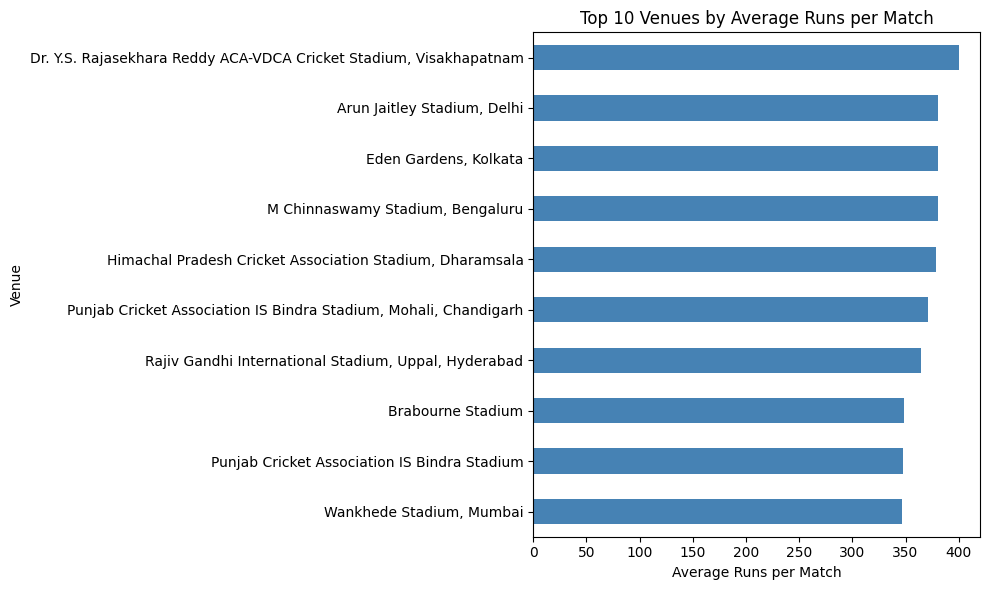

In [34]:
top_venues = venue_avg.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_venues.plot(
    kind='barh',
    color='steelblue'
)

plt.title('Top 10 Venues by Average Runs per Match')
plt.xlabel('Average Runs per Match')
plt.ylabel('Venue')

plt.tight_layout()

plt.savefig(
    'reports/figures/top_10_venues_average_runs.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Step 3 — Top 10 Venues by Average Runs

Chart shows the top 10 venues by average total runs per match. Venues like Wankhede and Chinnaswamy consistently produce high scores.

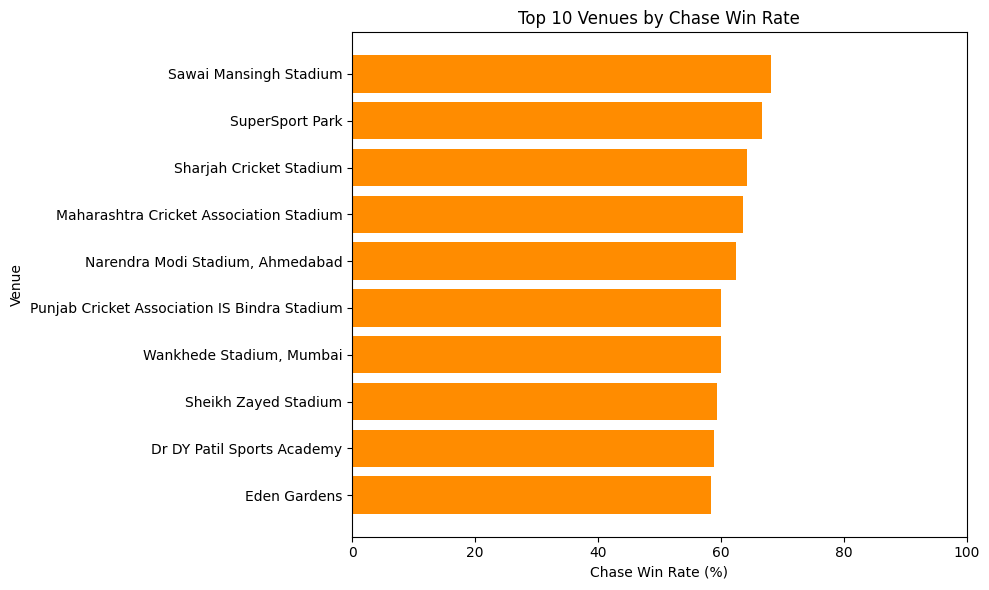

In [44]:
top_chase_venues = (
    venue_df
    .sort_values('Chase_Win_Rate', ascending=False)
    .head(10)
    .sort_values('Chase_Win_Rate')
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_chase_venues.index,
    top_chase_venues['Chase_Win_Rate'],
    color='darkorange'
)

plt.xlabel('Chase Win Rate (%)')
plt.ylabel('Venue')
plt.title('Top 10 Venues by Chase Win Rate')

plt.xlim(0, 100)

plt.tight_layout()

plt.savefig(
    'reports/figures/top_10_venues_chase_win_rate.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()